<a href="https://colab.research.google.com/github/juliosdutra/AulaFCE/blob/main/SimulaTratamentoBio.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Importando o módulo desenvolvido

In [1]:
!git clone https://github.com/juliosdutra/AulaFCE.git -qq

In [2]:
from AulaFCE.TratamentoBio import (
    ParametrosBioreator,
    vmax_arrhenius,
    simula_bioreator,
)

# Bloco de ajuda

In [8]:
print(ParametrosBioreator.__doc__)


    # Parâmetros do Biorreator

    Armazena os parâmetros do modelo de Michaelis-Menten
    com dependência de temperatura via Arrhenius.

    ## Atributos

    - Vmax_ref: velocidade máxima de referência.
    - Km: constante de Michaelis-Menten.
    - Ea: energia de ativação.
    - R: constante universal dos gases.
    - Tref: temperatura de referência.
    


In [9]:
print(vmax_arrhenius.__doc__)


    Calcula a velocidade máxima de consumo (Vmax)
    utilizando a equação de Arrhenius.

    Parameters
    ----------
    T : float
        Temperatura em graus Celsius.
    params : ParametrosBioreator
        Parâmetros do modelo.

    Returns
    -------
    float
        Valor de Vmax para a temperatura especificada.
    


In [10]:
print(simula_bioreator.__doc__)


    Simula o consumo de substrato em um biorreator.

    Parameters
    ----------
    S0 : float
        Concentração inicial de substrato (mg/L).
    tempo_final : float
        Tempo final de simulação (h).
    T : float
        Temperatura de operação (°C).
    params : ParametrosBioreator
        Parâmetros do modelo.

    Returns
    -------
    tempo : ndarray
        Vetor de tempo.
    concentracao : ndarray
        Perfil temporal da concentração de substrato.
    


# Executando a simulação

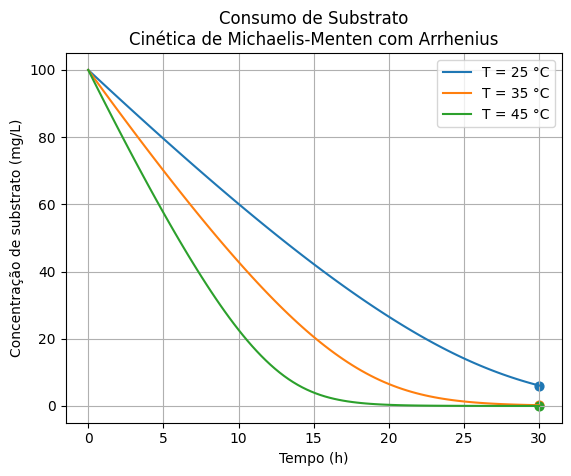

In [62]:
import matplotlib.pyplot as plt

# =====================================================
# Parâmetros do problema
# =====================================================

T_list = [25.0, 35.0, 45.0] # Temperatura (°C)
S0 = 100.0                  # Concentração inicial (mg/L)
t_final = 30.0              # horas
params = ParametrosBioreator()
resultados = {'T':[],
              'Vmax':[],
              'Sfinal':[]}

for T in T_list:

    tempo, subst = simula_bioreator(S0, t_final, T, params)

    vmax = vmax_arrhenius(T, params)

    plt.plot(tempo, subst, label=f'T = {T:.0f} °C')
    plt.scatter(tempo[-1], subst[-1], s=40)

    resultados['T'].append(T)
    resultados['Sfinal'].append(subst[-1])
    resultados['Vmax'].append(vmax)

plt.grid()
plt.legend()
plt.xlabel('Tempo (h)')
plt.ylabel('Concentração de substrato (mg/L)')
plt.title(
    'Consumo de Substrato\n'
    'Cinética de Michaelis-Menten com Arrhenius'
)
plt.show()

In [61]:
import pandas as pd

df = pd.DataFrame(resultados)

df = df.round({
    'Vmax': 2,
    'Sfinal': 3
})

df

,T,Vmax,Sfinal
0,25.0,5.00,6.073
1,35.0,7.41,0.220
2,45.0,10.70,0.002


# Análise dos resultados

Observa-se que a temperatura exerce forte influência sobre a velocidade de consumo do substrato. De acordo com a equação de Arrhenius, o aumento da temperatura provoca um aumento do valor de $V_{max}$, indicando maior atividade microbiana e, consequentemente, maior taxa de remoção do substrato.

Os valores de $V_{max}$ calculados para 25°C, 35°C e 45°C aumentam progressivamente, o que se reflete diretamente na inclinação das curvas de concentração. Para temperaturas mais elevadas, o substrato é consumido mais rapidamente, resultando em menores concentrações ao final do período de simulação.

Observa-se também que a velocidade de consumo não permanece constante ao longo do tempo. À medida que a concentração de substrato diminui, o termo de Michaelis-Menten

$$ \frac{S}{K_m+S} $$

também diminui, reduzindo gradualmente a taxa de reação. Como consequência, todas as curvas apresentam uma redução mais acentuada no início da simulação e uma tendência de desaceleração conforme o substrato é consumido.

Comparando os três cenários, a simulação a 45°C apresenta a remoção mais rápida e a menor concentração final de substrato, enquanto a simulação a 25°C apresenta a menor velocidade de consumo e a maior concentração residual ao final das 30 horas. O comportamento obtido é consistente com os princípios da cinética química e da modelagem de processos biotecnológicos.